# Logistic Regression for Text Classification

### Recall: Naive Bayes

In [1]:
from sklearn.datasets import fetch_20newsgroups
from pprint import pprint

# Load the 20 newsgroups dataset
newsgroups_train = fetch_20newsgroups(subset='train')
newsgroups_test = fetch_20newsgroups(subset='test')

In [2]:
pprint(list(newsgroups_train.target_names))

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']


In [3]:
for i in range(10):
    print("[Category]", newsgroups_train.target[i])
    print(newsgroups_train.data[i])
    print("==================================================")

[Category] 7
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----





[Category] 4
From: guykuo@carson.u.washington.edu (Guy Kuo)
Subject: SI Clock Poll - Final Call
Summary: Final call for SI clock reports
Keywords: SI,acceleration,clock,upgrade
Article-I.D.: shelley.1qvfo9INNc3s
Organization: University of Washington
Lines: 11
NNTP

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Train a Naive Bayes

# Transform the text data into numerical vectors
vectorizer = CountVectorizer(stop_words='english')
train_data = vectorizer.fit_transform(newsgroups_train.data)
test_data = vectorizer.transform(newsgroups_test.data)

# Train a Multinomial Naive Bayes classifier
clf_nb = MultinomialNB()
clf_nb.fit(train_data, newsgroups_train.target)

# Predict the class labels for the test data
predicted_nb = clf_nb.predict(test_data)

In [5]:
# Calculate the precision, recall, and F1-score of the classifier
report_nb = classification_report(newsgroups_test.target, predicted_nb)
print(report_nb)

              precision    recall  f1-score   support

           0       0.80      0.81      0.80       319
           1       0.65      0.80      0.72       389
           2       0.80      0.04      0.08       394
           3       0.55      0.80      0.65       392
           4       0.85      0.79      0.82       385
           5       0.69      0.84      0.76       395
           6       0.89      0.74      0.81       390
           7       0.89      0.92      0.91       396
           8       0.95      0.94      0.95       398
           9       0.95      0.92      0.93       397
          10       0.92      0.97      0.94       399
          11       0.80      0.96      0.87       396
          12       0.79      0.70      0.74       393
          13       0.88      0.87      0.87       396
          14       0.84      0.92      0.88       394
          15       0.81      0.95      0.87       398
          16       0.72      0.93      0.81       364
          17       0.93    

### Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression classifier
clf_lr = LogisticRegression(max_iter=1000) # do not coverage using the default max iteration!!
clf_lr.fit(train_data, newsgroups_train.target)

# Predict the class labels for the test data
predicted_lr = clf_lr.predict(test_data)

In [7]:
report_lr = classification_report(newsgroups_test.target, predicted_lr)
print(report_lr)

              precision    recall  f1-score   support

           0       0.76      0.71      0.73       319
           1       0.68      0.76      0.72       389
           2       0.75      0.69      0.72       394
           3       0.66      0.70      0.68       392
           4       0.77      0.80      0.79       385
           5       0.82      0.73      0.77       395
           6       0.79      0.88      0.83       390
           7       0.86      0.86      0.86       396
           8       0.91      0.92      0.92       398
           9       0.86      0.89      0.87       397
          10       0.91      0.94      0.93       399
          11       0.93      0.87      0.90       396
          12       0.69      0.72      0.70       393
          13       0.86      0.80      0.83       396
          14       0.92      0.90      0.91       394
          15       0.82      0.93      0.87       398
          16       0.71      0.87      0.79       364
          17       0.95    

Wait! This is only slightly better than NB.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(newsgroups_train.data)
X_test_tfidf = vectorizer_tfidf.transform(newsgroups_test.data)

clf_lr_tfidf = LogisticRegression()
clf_lr_tfidf.fit(X_train_tfidf, newsgroups_train.target)

# Predict the class labels for the test data
predicted_lr_tfidf = clf_lr_tfidf.predict(X_test_tfidf)

report_lr_tfidf = classification_report(newsgroups_test.target, predicted_lr_tfidf)
print(report_lr_tfidf)

              precision    recall  f1-score   support

           0       0.80      0.74      0.77       319
           1       0.69      0.79      0.74       389
           2       0.75      0.73      0.74       394
           3       0.72      0.72      0.72       392
           4       0.81      0.83      0.82       385
           5       0.83      0.74      0.78       395
           6       0.76      0.90      0.82       390
           7       0.90      0.89      0.90       396
           8       0.95      0.95      0.95       398
           9       0.88      0.92      0.90       397
          10       0.94      0.95      0.95       399
          11       0.94      0.88      0.91       396
          12       0.76      0.80      0.78       393
          13       0.89      0.83      0.85       396
          14       0.91      0.92      0.91       394
          15       0.81      0.94      0.87       398
          16       0.72      0.88      0.79       364
          17       0.96    

In [9]:
vectorizer_tfidf_2 = TfidfVectorizer(ngram_range=(1, 2)) # Using all features would be extremely large, maybe resulting out of memory error.
X_train_tfidf_2 = vectorizer_tfidf_2.fit_transform(newsgroups_train.data)
X_test_tfidf_2 = vectorizer_tfidf_2.transform(newsgroups_test.data)

print(len(vectorizer_tfidf_2.vocabulary_))

1181803


Too many features. At least my computer cannot handle so many features. We can do some feature selection here. 

In [11]:
from sklearn.feature_selection import SelectKBest, chi2

feature_selector = SelectKBest(chi2, k=500000)

X_train_selected = feature_selector.fit_transform(X_train_tfidf_2, newsgroups_train.target)
X_test_selected = feature_selector.transform(X_test_tfidf_2)

clf_lr_tfidf_2 = LogisticRegression()
clf_lr_tfidf_2.fit(X_train_selected, newsgroups_train.target)

# Predict the class labels for the test data
predicted_lr_tfidf_2 = clf_lr_tfidf_2.predict(X_test_selected)

report_lr_tfidf_2 = classification_report(newsgroups_test.target, predicted_lr_tfidf_2)
print(report_lr_tfidf_2)

              precision    recall  f1-score   support

           0       0.80      0.76      0.77       319
           1       0.65      0.77      0.71       389
           2       0.75      0.75      0.75       394
           3       0.72      0.73      0.73       392
           4       0.81      0.83      0.82       385
           5       0.82      0.73      0.77       395
           6       0.75      0.91      0.82       390
           7       0.90      0.90      0.90       396
           8       0.94      0.95      0.94       398
           9       0.87      0.90      0.88       397
          10       0.92      0.95      0.94       399
          11       0.93      0.89      0.91       396
          12       0.77      0.74      0.76       393
          13       0.89      0.78      0.83       396
          14       0.88      0.91      0.89       394
          15       0.77      0.93      0.84       398
          16       0.73      0.87      0.79       364
          17       0.95    

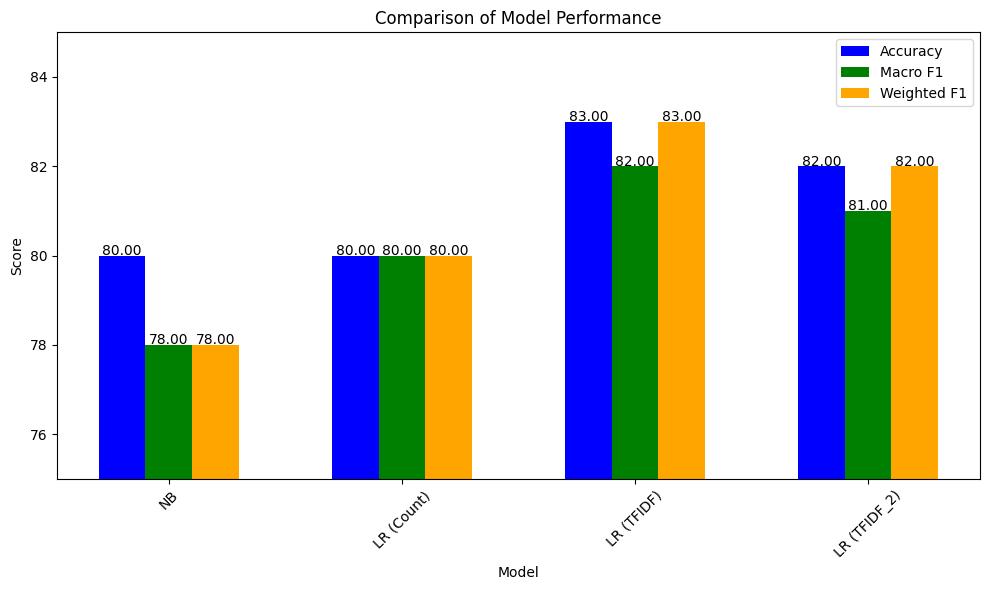

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Define the model names and their corresponding accuracy, macro F1, and micro F1 scores
model_names = ['NB', 'LR (Count)', 'LR (TFIDF)', 'LR (TFIDF_2)']  # Add more model names if needed
accuracy_scores = [80, 80, 83, 82]  # Replace with actual accuracy scores
macro_f1_scores = [78, 80, 82, 81]  # Replace with actual macro F1 scores
weighted_f1_scores = [78, 80, 83, 82]  # Replace with actual micro F1 scores

# Plot the bar graph
plt.figure(figsize=(10, 6))
bar_width = 0.2
index = np.arange(len(model_names))

plt.bar(index, accuracy_scores, width=bar_width, label='Accuracy', color='blue')
plt.bar(index + bar_width, macro_f1_scores, width=bar_width, label='Macro F1', color='green')
plt.bar(index + (2 * bar_width), weighted_f1_scores, width=bar_width, label='Weighted F1', color='orange')

# Customize the plot
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Comparison of Model Performance')
plt.xticks(index + bar_width, model_names, rotation=45)
plt.legend()

# Display the scores on top of the bars
for i in range(len(model_names)):
    plt.text(index[i], accuracy_scores[i] + 0.01, f"{accuracy_scores[i]:.2f}", ha='center', color='black')
    plt.text(index[i] + bar_width, macro_f1_scores[i] + 0.01, f"{macro_f1_scores[i]:.2f}", ha='center', color='black')
    plt.text(index[i] + (2 * bar_width), weighted_f1_scores[i] + 0.01, f"{weighted_f1_scores[i]:.2f}", ha='center', color='black')

plt.ylim(75, 85)
    
# Show the plot
plt.tight_layout()
plt.show()